<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [18]</a>'.</span>

In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 1
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/VarDynCM_metrics_train.csv"
COND_MODE = "grad"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


# VarDynCM — Variational Dynamical Consistency Model (GP / SPDE)

Fusion of **VarCM** (pairwise self-consistency, no prescribed SDE) and **DynCM** \
(spinup / physical time structure with Karras preconditioning).

**Key differences from DynCM**

| Aspect | DynCM | **VarDynCM** |
|---|---|---|
| Spin-up input | `IC + σ·ε` (forward SDE) | `σ_max · ε` (pure noise) |
| Physical input | interpolation between frames | **GT frame directly** (no interpolant) |
| Physical target | GT anchor via `anchor_mode` | physical-anchoring loss `L_phys` |
| Spin-up target | teacher EMA | IC-anchoring loss `L_IC` |
| Loss | `L_consistency` | `L_comp + λ_IC · L_IC + λ_phys · L_phys` |

Time axis and Karras preconditioner are **unchanged** from DynCM v7:

| Variable | Range | Meaning |
|---|---|---|
| Solver progress `s` | 0 → 1 | 0 = pure noise, 1 = clean |
| Diffusion time `t` | 1 → 0 | 1 = pure noise, 0 = clean |
| **Spin-up** | s ∈ [0, 0.3], t ∈ [0.7, 1] | noise → IC (frame 0) |
| **Physical** | s ∈ [0.3, 1], t ∈ [0, 0.7] | IC → frame 1 → … → frame C−1 |


## 🛠️ Setup

### GPU Check

In [4]:
!nvidia-smi

Sat Aug  8 01:22:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:E3:00.0 Off |                    0 |
| N/A   87C    P0            396W /  400W |   64329MiB /  95830MiB |     99%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

## 📖 Theory — VarDynCM Loss

### Pairwise composition  (replaces teacher-consistency in spinup)
$$\mathcal{L}_{\mathrm{comp}} = \mathbb{E}_{t>t'>t''}\bigl[\|g(x,t,t'') - g(g(x,t,t'), t', t'')\|^2\bigr]$$
- Spin-up: $x = \sigma_{\max}\varepsilon$ (pure noise — no SDE forward required)
- Physical: $x = x_k$ (nearest GT frame — no temporal interpolation)

### IC anchoring  (replaces teacher EMA for spin-up)
$$\mathcal{L}_{\mathrm{IC}} = \mathbb{E}_{t > t_{\mathrm{IC}}}\bigl[\|g(\sigma_{\max}\varepsilon,\, t,\, t_{\mathrm{IC}}) - x_0\|^2\bigr]$$
Directly trains the model to denoise from pure noise to IC at the spin-up / physical boundary.

### Physical anchoring  (replaces interpolated targets)
$$\mathcal{L}_{\mathrm{phys}} = \frac{1}{C-1}\sum_{k=0}^{C-2}\|g(x_k, t_k, t_{k+1}) - x_{k+1}\|^2, \quad t_k = t_{\mathrm{IC}}\tfrac{C-1-k}{C-1}$$
GT frame $x_k$ is used directly as starting point — no interpolation between frames.

### Karras preconditioner  (unchanged, $\sigma_{\max}=3$)
$$g_\theta(x,t,t') = c_{\mathrm{skip}}(\sigma(t))\cdot x + c_{\mathrm{out}}(\sigma(t))\cdot F_\theta(x,y,t,t')$$
With $\sigma_{\max}=3$: $c_{\mathrm{skip}}=0.10$ in spin-up (vs 0.01 before), giving a meaningful input anchor.


## 🛠️ Setup
### Imports

In [6]:
import json
import math
import os
import zipfile
import glob
import importlib
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # -> consistency/
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

from consistency_models.consistency_models_VarDynCM import (
    VarDynCMTraining,
    VarDynCMOutput,
    VarDynCMSamplingAndEditing,   # VarDynCM-aware sampler (applies grad_cond at inference)
)
from consistency_models.utils import (
    timesteps_schedule,
    update_ema_model_,
    ema_decay_rate_schedule,
)


## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

$N = $ `window_size` physical time steps.  
The transition point is $t_\mathrm{IC} = 1/N$ (one Karras step for spin-up, $N-1$ for physical evolution).

In [7]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "../../../data/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset>
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * lat        (lat) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 ...
    y          (time, lat, lon) float32 ...
    OI         (time, lat, lon) float64 ...
    H11        (lat, lon) float32 ...
    H22        (lat, lon) float32 ...
    H12        (lat, lon) float32 ...
    Time       (time) int64 ...
    longitude  (lon) int64 ...
    latitude   (lat) int64 ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('lat', 'lon')  shape=(128, 128)  dtype=float32
  H22

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size C      = 5
t_IC (transition)  = 0.2000  (= 1/C)
Spatial size       = 128 x 128
TrainingItem: input (y) (5, 128, 128)  tgt (x) (5, 128, 128)


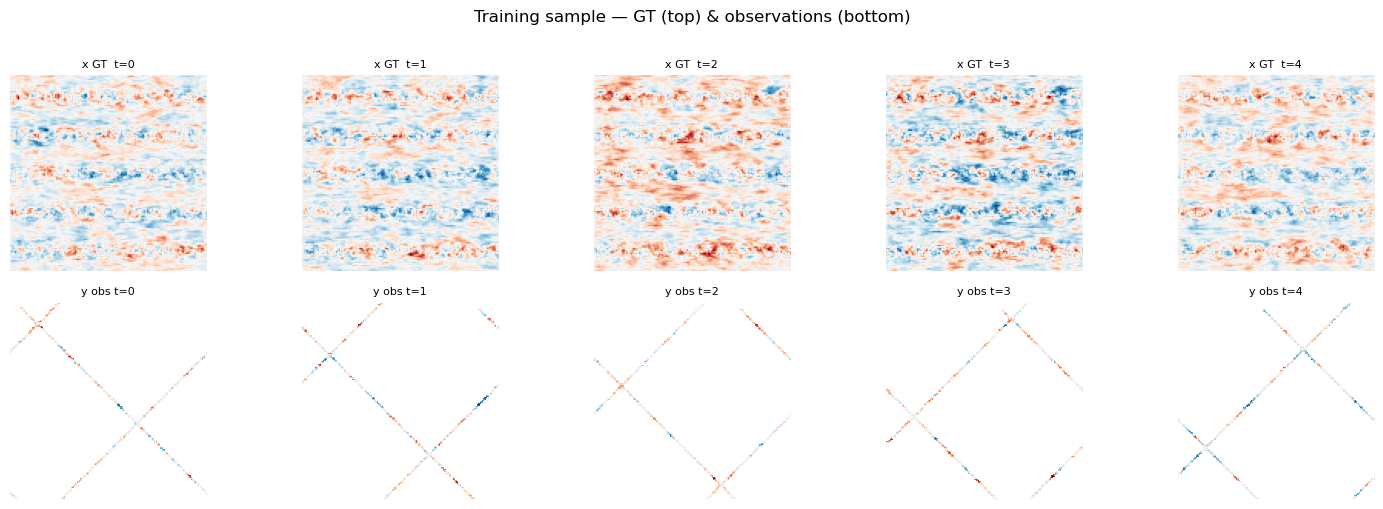

In [8]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C  = datamodule.window_size
H, W = sample.tgt.shape[-2], sample.tgt.shape[-1]
t_IC = 1.0 / C   # transition point between spin-up and physical regime

print(f"window_size C      = {C}")
print(f"t_IC (transition)  = {t_IC:.4f}  (= 1/C)")
print(f"Spatial size       = {H} x {W}")
print(f"TrainingItem: input (y) {sample.input.shape}  tgt (x) {sample.tgt.shape}")

fig, axes = plt.subplots(2, C, figsize=(3 * C, 5))
for t_idx in range(C):
    axes[0, t_idx].imshow(sample.tgt[t_idx],   origin="lower", cmap="RdBu_r")
    axes[0, t_idx].set_title(f"x GT  t={t_idx}", fontsize=8)
    axes[0, t_idx].axis("off")
    axes[1, t_idx].imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    axes[1, t_idx].set_title(f"y obs t={t_idx}", fontsize=8)
    axes[1, t_idx].axis("off")
plt.suptitle("Training sample — GT (top) & observations (bottom)", y=1.01)
plt.tight_layout()
plt.show()

### UNet Building Blocks

The UNet takes:
- **x**: `(B, 1, H, W)` — current state at diffusion time $t$ (single physical field)
- **y**: `(B, C, H, W)` — full observation window (all $N$ time steps) — `NaN` = unobserved
- **mask**: `(B, C, H, W)` — binary mask derived from `y`
- **t, t'**: `(B,)` — current and target diffusion times

Total input channels = $1 + C + C = 2C + 1$.  
Output = `(B, 1, H, W)` — predicted state at $t'$.

Spatial size 100×100 is padded to the nearest multiple of 8 before the forward pass.

In [9]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeEmbedding(nn.Module):
    """Fourier embedding for a scalar t ∈ [0,1]."""
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Spatial padding (100×100 → 104×104, multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### UNet

Input: `cat(x, y_filled, mask_y, w_obs)` → $3C+1$ channels, output: `1` channel.  
Two separate `TimeEmbedding` for $t$ and $t'$, concatenated → $2 \times$ `time_level_channels` conditioning.

**Key design** — observation weight vector $\mathbf{w}(t) \in [0,1]^C$:  
The UNet computes this vector internally from $t$, using exactly the same interpolation rule as the GT target in `_make_regime_input`:
- **Spin-up** ($t \le t_\text{IC}$): $w_0 = 1$, others 0 → only the IC obs is "local"  
- **Physical** ($t \in [t_k, t_{k+1}]$): $w_k = 1-\lambda$, $w_{k+1} = \lambda$, others 0

This weight vector is broadcast spatially and appended as $C$ additional input channels. The model thereby always knows which obs channels are temporally relevant to the current step — **no channel permutation needed**, and the correspondence is consistent with the supervised training targets.


In [10]:
@dataclass
class UNetConfig:
    # channels = C = window_size (number of physical time steps)
    channels: int = 5
    time_level_channels: int = 128
    spinup_boundary: float = 0.7
    grad_j_channels: int   = 0      # 0 = no grad cond; 1 = ∇J; 2 = obs(y,mask); 3 = obs+∇J
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


def _compute_obs_weights(t: Tensor, C: int, spinup_boundary: float = 0.7) -> Tensor:
    """
    Matches _make_regime_input (consistency_models_DynCM.py) exactly.
    physical_steps = linspace(0, spinup_boundary, C)  [INCREASING]
    physical_steps[k] <-> frame C-1-k
      k=0:   t=0               -> frame C-1 (last)
      k=C-1: t=spinup_boundary -> frame 0  (IC)

    - spinup  (t > spinup_boundary): w = [1, 0, ..., 0]  (only IC = frame 0)
    - physical (t <= spinup_boundary): interpolate between adjacent frame anchors
    """
    B      = t.shape[0]
    device, dtype = t.device, t.dtype
    phys_step_size = spinup_boundary / max(C - 1, 1)
    physical_steps = torch.linspace(0.0, spinup_boundary, C, device=device, dtype=dtype)

    t_clamped = t.clamp(0.0, spinup_boundary).unsqueeze(1)
    idx = torch.searchsorted(
        physical_steps.unsqueeze(0).expand(B, -1).contiguous(),
        t_clamped,
    ).squeeze(1).clamp(1, C - 1)

    b_idx = torch.arange(B, device=device)
    a = ((physical_steps[idx] - t.clamp(0.0, spinup_boundary)) / phys_step_size).clamp(0., 1.)

    w = torch.zeros(B, C, device=device, dtype=dtype)
    w[b_idx, C - idx]     = a          # "prev" = next fwd-time frame
    w[b_idx, C - 1 - idx] = 1.0 - a   # "curr" = IC-side frame

    # Override spinup: only IC (frame 0) is relevant
    spinup = (t > spinup_boundary)
    w[spinup]    = 0.0
    w[spinup, 0] = 1.0

    return w


class UNet(nn.Module):
    """
    UNet for the unified physical-diffusion consistency model.

    Forward signature: UNet(x, y, t, t_prime)
      x       : (B, 1,   H, W)  -- current state at diffusion time t (spin-up or physical)
      y       : (B, C,   H, W)  -- full observation window (NaN = unobserved)
      t       : (B,)            -- current diffusion time
      t_prime : (B,)            -- target diffusion time

    Input channels = 3*C + 1  (x | y_filled | mask_y | w_obs)
    Output         = 1 channel (predicted state at t')

    w_obs is the temporal interpolation weight vector w(t) ∈ [0,1]^C,
    computed internally from t using _compute_obs_weights. It tells the model
    which observation channels are "local" to the current diffusion time:
      - spin-up : w = [1, 0, ..., 0]
      - physical between frames k and k+1: w_k = 1-λ, w_{k+1} = λ, others 0
    This is consistent with the supervised GT target construction in _make_regime_input.
    """
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        top = config.top_blocks_channels[0]

        # input: cat(x:1, y_filled:C, mask_y:C, w_obs:C) = 3C+1 channels
        self.input_projection = nn.Conv2d(3 * C + 1, top, kernel_size=3, padding="same")

        # Separate embeddings for t and t'
        self.time_embedding_t  = TimeEmbedding(config.time_level_channels, config.time_level_scale)
        self.time_embedding_tp = TimeEmbedding(config.time_level_channels, config.time_level_scale)

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        # Output: 1 channel (single physical state)
        self.output_projection = nn.Conv2d(top, 1, kernel_size=3, padding="same")

        # Zero-init variational gradient projection (physical-time ∇J).
        if config.grad_j_channels > 0:
            self.grad_j_projection = nn.Conv2d(
                config.grad_j_channels, top, kernel_size=3, padding="same"
            )
            nn.init.zeros_(self.grad_j_projection.weight)
            nn.init.zeros_(self.grad_j_projection.bias)

    def forward(self, x: Tensor, y: Tensor,
                t: Tensor, t_prime: Tensor,
                grad_cond: "Optional[Tensor]" = None) -> Tensor:
        """
        x       : (B, 1,   H, W)
        y       : (B, C,   H, W)   -- NaN where unobserved
        t       : (B,)             -- current diffusion time
        t_prime : (B,)             -- target diffusion time
        """
        B, C, H, W = y.shape
        mask_y = (~torch.isnan(y)).to(dtype=x.dtype)
        y_fill = torch.nan_to_num(y, nan=0.0)

        # Temporal observation weights: (B, C) → broadcast to (B, C, H, W)
        # w(t) encodes which obs channels are local to the current diffusion step.
        # Uses the same interpolation rule as the supervised GT target — consistent by design.
        w_obs = _compute_obs_weights(t.to(dtype=x.dtype), C, self.config.spinup_boundary)  # (B, C)
        w_spatial = w_obs[:, :, None, None].expand(B, C, H, W)        # (B, C, H, W)

        # Concatenate along channel dim and pad to multiple of 8
        inp = torch.cat([x, y_fill, mask_y, w_spatial], dim=1)   # (B, 3C+1, H, W)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h = self.input_projection(inp)
        if grad_cond is not None and hasattr(self, "grad_j_projection"):
            h = h + self.grad_j_projection(grad_cond)

        emb_t  = self.time_embedding_t(t)
        emb_tp = self.time_embedding_tp(t_prime)
        time_level = torch.cat([emb_t, emb_tp], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# ---- Sanity check ----
C = datamodule.window_size
_unet = UNet(UNetConfig(channels=C)).cpu()
try:
    summary(
        _unet,
        input_size=(
            (1, 1,   100, 100),  # x  (current state, 1 channel)
            (1, C,   100, 100),  # y  (full obs window, C channels)
            (1,),                # t
            (1,),                # t'
        ),
        col_names=["input_size", "output_size", "num_params"],
        verbose=0,
        device="cpu",
    )
except Exception as e:
    n_params = sum(p.numel() for p in _unet.parameters())
    print(f"[torchinfo unavailable: {e}]")
    print(f"UNet parameters: {n_params:,}")

# Quick CPU forward pass — verify shapes and w_obs values
_x = torch.randn(1, 1, 100, 100)
_y = torch.randn(1, C, 100, 100)
_y[0, :, :5, :5] = float("nan")
_t = torch.rand(1)
with torch.no_grad():
    _out = _unet(_x, _y, _t, _t)
print(f"[OK] UNet forward: x {_x.shape} + y {_y.shape} -> {_out.shape}  (3C+1={3*C+1} input channels)")
print(f"[OK] Parameters: {sum(p.numel() for p in _unet.parameters()):,}")

# Verify w_obs for a few representative times
_sb = 0.7  # must match training spinup_boundary
print(f"\nw_obs sanity check (C={C}, spinup_boundary={_sb}):")
for t_test in [0.0, 0.1, 0.35, _sb - 0.01, _sb, _sb + 0.01, 0.9, 1.0]:
    w = _compute_obs_weights(torch.tensor([t_test]), C, spinup_boundary=_sb)
    print(f"  t={t_test:.3f}  →  w={w[0].tolist()}  (sum={w[0].sum().item():.3f})")


[OK] UNet forward: x torch.Size([1, 1, 100, 100]) + y torch.Size([1, 5, 100, 100]) -> torch.Size([1, 1, 100, 100])  (3C+1=16 input channels)
[OK] Parameters: 32,997,889

w_obs sanity check (C=5, spinup_boundary=0.7):
  t=0.000  →  w=[0.0, 0.0, 0.0, 0.0, 1.0]  (sum=1.000)
  t=0.100  →  w=[0.0, 0.0, 0.0, 0.5714285969734192, 0.4285714030265808]  (sum=1.000)
  t=0.350  →  w=[0.0, 0.0, 1.0, 0.0, 0.0]  (sum=1.000)
  t=0.690  →  w=[0.9428572058677673, 0.05714280530810356, 0.0, 0.0, 0.0]  (sum=1.000)
  t=0.700  →  w=[1.0, 0.0, 0.0, 0.0, 0.0]  (sum=1.000)
  t=0.710  →  w=[1.0, 0.0, 0.0, 0.0, 0.0]  (sum=1.000)
  t=0.900  →  w=[1.0, 0.0, 0.0, 0.0, 0.0]  (sum=1.000)
  t=1.000  →  w=[1.0, 0.0, 0.0, 0.0, 0.0]  (sum=1.000)


### LightningModule

Wraps `VarDynCMTraining`.  
Three losses logged separately: `L_comp`, `L_IC`, `L_phys`.


In [11]:
@dataclass
class LitVarDynCMConfig:
    initial_ema_decay_rate:       float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr:                           float = 1e-4
    betas:                        tuple = (0.9, 0.999)
    lr_scheduler_start_factor:    float = 1e-4
    lr_scheduler_iters:           int   = 2_000
    total_training_steps:         int   = 10_000   # fallback only — overridden dynamically in configure_optimizers
    lambda_reg_init:              float = 1.0


class LitVarDynCM(pl.LightningModule):
    """
    Lightning wrapper for VarDynCM.

    When conditioning_mode="grad":
      - obs_cost, prior_cost, lambda_reg are jointly optimised.
      - ∇J(x,y,t) is computed in physical regime only; zeros in spin-up.
    """

    def __init__(
        self,
        var_dyncm_training: VarDynCMTraining,
        student_model:      nn.Module,
        teacher_model:      nn.Module,
        config:             LitVarDynCMConfig,
        obs_cost:           nn.Module = None,
        prior_cost:         nn.Module = None,
    ):
        super().__init__()
        self.training_module = var_dyncm_training
        self.student_model   = student_model
        self.teacher_model   = teacher_model
        self.obs_cost        = obs_cost
        self.prior_cost      = prior_cost
        self.config          = config
        self._total_steps    = config.total_training_steps
        self._last_N         = var_dyncm_training.initial_timesteps

        self.lambda_reg = (
            nn.Parameter(torch.tensor(config.lambda_reg_init, dtype=torch.float32))
            if var_dyncm_training.conditioning_mode in ("grad", "obs+grad") else None
        )

        for p in self.teacher_model.parameters():
            p.requires_grad_(False)
        self.teacher_model.load_state_dict(self.student_model.state_dict())

    def configure_optimizers(self):
        if self.trainer is not None:
            try:
                self._total_steps = int(self.trainer.estimated_stepping_batches)
            except Exception:
                pass
        params = list(self.student_model.parameters())
        if self.obs_cost   is not None: params += list(self.obs_cost.parameters())
        if self.prior_cost is not None: params += list(self.prior_cost.parameters())
        if self.lambda_reg is not None: params.append(self.lambda_reg)
        opt   = torch.optim.Adam(params, lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters)
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]

    def training_step(self, batch, batch_idx: int):
        if self.lambda_reg is not None:
            self.lambda_reg.data.clamp_(min=0.0)
        out: VarDynCMOutput = self.training_module(
            self.student_model, self.teacher_model,
            batch.tgt, batch.input,
            self.global_step, self._total_steps,
            obs_cost=self.obs_cost, prior_cost=self.prior_cost, lambda_reg=self.lambda_reg,
        )
        self._last_N = out.num_timesteps
        log_dict = {
            "train_loss": out.loss, "L_comp": out.loss_comp,
            "L_IC": out.loss_IC,   "L_phys": out.loss_phys,
            "L_obs": out.loss_obs, "L_ae": out.loss_ae,
            "N_steps": float(out.num_timesteps),
        }
        if self.lambda_reg is not None:
            log_dict["lambda_reg"] = self.lambda_reg.detach()
        self.log_dict(log_dict, prog_bar=True, on_step=True, on_epoch=False)
        return out.loss

    def on_train_batch_end(self, outputs, batch, batch_idx):
        ema_decay = ema_decay_rate_schedule(
            self._last_N, self.config.initial_ema_decay_rate,
            self.training_module.initial_timesteps)
        update_ema_model_(self.teacher_model, self.student_model, ema_decay)

    def validation_step(self, batch, batch_idx):
        sb  = self.training_module.spinup_boundary
        B, C, H, W = batch.tgt.shape
        dev = batch.tgt.device
        IC  = batch.tgt[:, [0], :, :]
        noise = torch.randn(B, 1, H, W, device=dev, dtype=batch.tgt.dtype) * self.training_module.sigma_max
        t_sp = torch.full((B,), sb + 0.15, device=dev, dtype=batch.tgt.dtype)
        t_IC = torch.full((B,), sb,        device=dev, dtype=batch.tgt.dtype)
        from consistency_models.consistency_models_VarDynCM import _fwd as _vd_fwd
        pred = _vd_fwd(self.student_model, noise, batch.input, t_sp, t_IC,
                       sb, conditioning_mode="none")
        val_loss = F.mse_loss(pred, IC)
        self.log("val_loss", val_loss, prog_bar=True, on_epoch=True)
        return val_loss


## 🚀 Training

### Unified timeline — time grid visualisation

Before training, let's visualise the unified time grid $\{t_0,\dots,t_N\}$ for a given
`num_timesteps` to see how the Karras grid partitions the spin-up and physical regimes.

In [12]:
from consistency_models.consistency_models_VarDynCM import (
    VarDynCMTraining,
    VarDynCMSamplingAndEditing,
)
from consistency_models.consistency_models_DynCM import compute_sigma_spinup
from consistency_models.utils import timesteps_schedule

### TensorBoard

### Training Loop

In [13]:
import shutil

# Conditioning mode — controls grad_cond passed to the UNet:
#   "none"     : no extra conditioning  (equivalent to DynCM)   grad_j_channels=0
#   "grad"     : ∇J(x,y,t) in physical regime, 0 in spin-up     grad_j_channels=1
#   "obs"      : cat(y_local, mask_local) in physical regime     grad_j_channels=2
#   "obs+grad" : cat(y_local, mask_local, ∇J) in phys. regime   grad_j_channels=3
COND_MODE = "obs"

# RESET_TRAINING set by the parameters cell above
LOG_DIR     = f"logs_CT_VarDynCM_spde_{COND_MODE.replace('+', '_')}"
C                 = datamodule.window_size
SPINUP_BOUNDARY   = 0.7
SIGMA_MAX         = 3.0       # c_skip=0.10 in spinup (vs 0.01 with sigma_max=10)

# v3: DynCM-style L_comp — GT-based intermediate input + GT anchor target for
#     physical regime (identical supervision structure as DynCM, fixes circular
#     bootstrap that caused variance explosion in v2).
#     v2 also included: L_ae (prior_cost training) + temporal t-snap +
#     VarDynCMSamplingAndEditing (grad_cond at inference).
_GRAD_CH_MAP    = {"none": 0, "grad": 1, "obs": 2, "obs+grad": 3}
GRAD_J_CHANNELS = _GRAD_CH_MAP[COND_MODE]

import consistency_models.consistency_models_VarDynCM as _vdcm_mod
importlib.reload(_vdcm_mod)
from consistency_models.consistency_models_VarDynCM import (
    VarDynCMTraining, VarDynCMObsCost, VarDynCMPriorCost,
    VarDynCMSamplingAndEditing,
)

obs_cost   = VarDynCMObsCost(sigma_obs=1.0, spinup_boundary=SPINUP_BOUNDARY).to("cuda")
prior_cost = VarDynCMPriorCost(dim_ae=32).to("cuda")

vdcm_training = VarDynCMTraining(
    spinup_boundary   = SPINUP_BOUNDARY,
    sigma_max=SIGMA_MAX,
    initial_timesteps = 5, final_timesteps=50,
    lambda_IC=1.0, lambda_phys=1.0, lambda_obs=1.0, lambda_ae=1.0,
    conditioning_mode = COND_MODE,
)

# VarDynCM-aware sampler: uses _fwd at each step so grad_cond is applied
# during inference (conditioning_mode determines what's computed).
consistency_sampling = VarDynCMSamplingAndEditing(
    sigma_max=SIGMA_MAX,
    spinup_boundary=SPINUP_BOUNDARY,
    conditioning_mode=COND_MODE,
)

cfg = UNetConfig(channels=C, spinup_boundary=SPINUP_BOUNDARY, grad_j_channels=GRAD_J_CHANNELS)
student_model = UNet(cfg).to("cuda")
teacher_model = UNet(cfg).to("cuda")

lit_model = LitVarDynCM(
    var_dyncm_training = vdcm_training,
    student_model=student_model, teacher_model=teacher_model,
    config=LitVarDynCMConfig(
        initial_ema_decay_rate=0.95, student_model_ema_decay_rate=0.99993,
        lr=1e-4, lr_scheduler_start_factor=1e-4, lr_scheduler_iters=2_000,
        lambda_reg_init=1.0,
    ),
    obs_cost=obs_cost, prior_cost=prior_cost,
)

# Guard: catch architecture mismatch before training starts
assert lit_model.student_model.config.grad_j_channels == GRAD_J_CHANNELS, (
    f"Architecture mismatch: model has grad_j_channels="
    f"{lit_model.student_model.config.grad_j_channels} "
    f"but COND_MODE='{COND_MODE}' requires {GRAD_J_CHANNELS}. "
    f"Re-run this cell from the top with the correct COND_MODE."
)

CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

def _is_valid_ckpt(path: str) -> bool:
    import zipfile
    try:
        with zipfile.ZipFile(path): pass
        return True
    except Exception:
        return False

def find_resume_ckpt(ckpt_dir: str) -> "Optional[str]":
    """Return the best valid checkpoint path, or None to start from scratch."""
    if not os.path.isdir(ckpt_dir):
        return None
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.isfile(last) and _is_valid_ckpt(last):
        print(f"[RESUME] last checkpoint: {last}")
        return last
    if os.path.isfile(last):
        print("[WARN] last.ckpt corrupted — scanning for best valid checkpoint.")
    candidates = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p) and _is_valid_ckpt(p)],
        key=lambda p: float(os.path.basename(p).split("val_loss=")[-1].split("-")[0])
        if "val_loss=" in os.path.basename(p) else [float("inf")],
    )
    if candidates:
        print(f"[RESUME] best checkpoint: {candidates[0]}")
        return candidates[0]
    print("[INFO] No valid checkpoint found — starting from scratch.")
    return None

if RESET_TRAINING:
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    print(f"RESET_TRAINING=True -- starting from scratch")
    resume_ckpt = None
else:
    resume_ckpt = find_resume_ckpt(CKPT_DIR)

trainer = pl.Trainer(enable_progress_bar=False, 
    max_epochs=MAX_EPOCHS, accelerator="gpu", devices=1,
    gradient_clip_val=0.5, accumulate_grad_batches=3,
    limit_train_batches=1000, limit_val_batches=100, inference_mode=False,
    logger=pl.loggers.CSVLogger(LOG_DIR, name="", version=""),
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            monitor="val_loss", save_top_k=3, save_last=True,
            filename="{val_loss:.5f}-{epoch:03d}",
            dirpath=CKPT_DIR,
        ),
        pl.callbacks.LearningRateMonitor(),
    ],
)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit_model, datamodule=datamodule, ckpt_path=resume_ckpt)


[RESUME] last checkpoint: logs_CT_VarDynCM_spde_obs/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


HPU available: False, using: 0 HPUs


...

[progress] epoch 1997/2000 | L_IC=0.0170 | L_ae=0.0000 | L_comp=0.0001 | L_obs=0.0006 | L_phys=0.0194 | N_steps=50.0000 | train_loss=0.0371 | val_loss=0.8592


[progress] epoch 1998/2000 | L_IC=0.0238 | L_ae=0.0000 | L_comp=0.0009 | L_obs=0.0005 | L_phys=0.0185 | N_steps=50.0000 | train_loss=0.0438 | val_loss=0.8582


[progress] epoch 1999/2000 | L_IC=0.0445 | L_ae=0.0000 | L_comp=0.0006 | L_obs=0.0006 | L_phys=0.0341 | N_steps=50.0000 | train_loss=0.0798 | val_loss=0.8560


[progress] epoch 2000/2000 | L_IC=0.0256 | L_ae=0.0000 | L_comp=0.0022 | L_obs=0.0016 | L_phys=0.0176 | N_steps=50.0000 | train_loss=0.0470 | val_loss=0.8625


`Trainer.fit` stopped: `max_epochs=2000` reached.


## 🎲 Sampling & Evaluation

### Checkpoint Loading

In [14]:
MODEL_PATH = os.path.join(LOG_DIR, "best_model")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

# Load best checkpoint
ckpt_dir = os.path.join(LOG_DIR, "checkpoints")
ckpts    = sorted(glob.glob(os.path.join(ckpt_dir, "*.ckpt")))
if ckpts:
    print(f"Loading checkpoint: {ckpts[0]}")
    lit_model = LitVarDynCM.load_from_checkpoint(
        ckpts[0],
        var_dyncm_training = vdcm_training,
        student_model      = student_model,
        teacher_model      = teacher_model,
        config             = lit_model.config,
        obs_cost           = obs_cost,
        prior_cost         = prior_cost,
    )
    student_model = lit_model.student_model.eval().to(device)
else:
    print("No checkpoint found — using current model weights")
    student_model = lit_model.student_model.eval().to(device)


Loading checkpoint: logs_CT_VarDynCM_spde_obs/checkpoints/last-v1.ckpt


### Test Batch

In [15]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

# m_norm/s_norm/start_t needed by the Publication Figures cell below AND
# the Metrics cell (now at the end of the notebook) -- defined once, early,
# here so both can use it regardless of cell order.
m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]

[rank: 0] Global seed set to 42


### Ensemble Generation

The sampler traverses the unified time grid from $s=0$ (pure noise) to $s=1$ (clean):

| Phase | Solver time $s$ | Diffusion time $t$ | Behaviour |
|---|---|---|---|
| **Spin-up** | $[0, \text{SPINUP\_FRAC}] \approx [0, 0.3]$ | $[0.7, 1]$ | Noise → IC (frame 0) |
| **Physical** | $[\text{SPINUP\_FRAC}, 1] \approx [0.3, 1]$ | $[0, 0.7]$ | IC → frame 1 → … → frame C−1 |

- `spinup_boundary` $= 1 - \text{SPINUP\_FRAC} = 0.7$ in diffusion time coordinates.
- Physical frame $k$ is anchored at $t_k = \text{sb} \times (C-1-k)/(C-1)$, reached at $s_k = 1 - t_k$.
- With `NSTEPS = 4C+1`, the IC appears at step $\approx C+1$ (solver time $\approx 0.3$) and frames are spaced ~3 steps apart.
- The full observation window $\mathbf{y}$ conditions every step.


In [16]:
# N_SAMPLES set by the parameters cell above
# NSTEPS = 5*C: gives C physical steps adjacent in the display strip
# (with display stride = round(sb*(NSTEPS-1)/(C-1)) = 4 for C=5, sb=0.7)
NSTEPS = 5 * datamodule.window_size   # 25 for C=5

H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]
y_dev = batch.input.to(device=device, dtype=dtype)

samples_list    = []
samples_process = []

# lambda_reg is an nn.Parameter (or None for "none"/"obs" modes)
_lambda_reg = getattr(lit_model, "lambda_reg", None)

for _ in range(N_SAMPLES):
    noise = torch.randn(1, 1, H, W, device=device, dtype=dtype)
    with torch.no_grad():
        final_x, process, phys_indices = consistency_sampling(
            student_model,
            noise,
            y_dev[:1],
            nsteps         = NSTEPS,
            obs_cost       = obs_cost,      # used for "grad" / "obs+grad" modes
            prior_cost     = prior_cost,    # used for "grad" / "obs+grad" modes
            lambda_reg     = _lambda_reg,   # None for "none" / "obs" modes
            clip_denoised  = False,
        )
    samples_list.append(final_x.cpu())
    samples_process.append(process.cpu())

phys_indices_list = phys_indices
print(f"\n[OK] {N_SAMPLES} ensemble members generated  (nsteps={NSTEPS})")
print(f"Physical frame indices (IC→last): {phys_indices_list}")
print(f"  → solver_times: {[f'{si/(NSTEPS-1):.2f}' for si in phys_indices_list]}")
print(f"  IC expected at s ≈ {1-SPINUP_BOUNDARY:.2f}  (step ~{round((1-SPINUP_BOUNDARY)*(NSTEPS-1))})")
print(f"Process shape: {samples_process[0].shape}  (nsteps, B=1, 1, H, W)")



[OK] 1 ensemble members generated  (nsteps=25)
Physical frame indices (IC→last): [7, 11, 16, 20, 24]
  → solver_times: ['0.29', '0.46', '0.67', '0.83', '1.00']
  IC expected at s ≈ 0.30  (step ~7)
Process shape: torch.Size([25, 1, 1, 128, 128])  (nsteps, B=1, 1, H, W)


### Ensemble


In [17]:
# Stack samples using the computed physical indices (IC-first order)
def extract_physical_trajectory(proc_tensor: torch.Tensor, idx_list) -> torch.Tensor:
    """proc_tensor: (nsteps+1, 1, 1, H, W) -> (C, H, W)"""
    return proc_tensor[idx_list, 0, 0, :, :]   # (C, H, W)


traj_list  = [extract_physical_trajectory(p, phys_indices_list) for p in samples_process]
traj_stack = torch.stack(traj_list, dim=0).numpy()   # (N, C, H, W)

ens_mean_traj = traj_stack.mean(axis=0)   # (C, H, W)
ens_std_traj  = traj_stack.std(axis=0)    # (C, H, W)
gt_np         = batch.tgt[0].float().numpy()   # (C, H, W)

### Publication Figures — comparison & uncertainty


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [18]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'VarDynCM_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C = datamodule.window_size
ws = C

obs_phys  = batch.input[0].float().numpy()   * s_norm + m_norm   # (C,H,W)
gt_phys   = batch.tgt[0].float().numpy()     * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + ws].astype(np.float32)
mean_phys = ens_mean_traj * s_norm + m_norm                         # (C,H,W)
std_phys  = ens_std_traj  * s_norm                                  # (C,H,W)
mbr0_phys = traj_stack[0]  * s_norm + m_norm                        # (C,H,W)
mbr1_phys = traj_stack[1]  * s_norm + m_norm                        # (C,H,W)

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

figures = [
    (obs_phys,  f'{FIG_TAG}_obs',          vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',           vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',           vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_vardyncm_mean', vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_vardyncm_spread',0.0,   vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0',      vmin_f, vmax_f, cmap_f),
    (mbr1_phys, f'{FIG_TAG}_member1',      vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)


IndexError: index 1 is out of bounds for axis 0 with size 1

### Transport process — sampling trajectory visualisation

Display **all diffusion steps** and then extract the **physical time steps** from the trajectory.  
The model maps noise at $t=1$ through the spin-up into the physical regime step by step.

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# ── Regime fractions ───────────────────────────────────────────────────────────
SPINUP_FRAC = round(1.0 - consistency_sampling.spinup_boundary, 2)   # 0.30 (not 0.300000004)

proc  = samples_process[0]
nfr   = proc.shape[0]

def solver_time(si):
    return round(si / max(nfr - 1, 1), 2)

phys_frames    = proc[phys_indices_list, 0, 0, :, :].numpy()
phys_times_lst = [solver_time(i) for i in phys_indices_list]
gt_phys_frames = batch.tgt[0].float().numpy()
obs_frames     = np.nan_to_num(batch.input[0].float().numpy(), nan=0.0)

vmin_all, vmax_all = -2, 2

# ── Build step_indices ─────────────────────────────────────────────────────────
# 4 evenly-spaced spin-up steps (0 … phys0-1) then, for each pair of consecutive
# physical frames, interleave: [phys_k, mid_k_k+1, phys_{k+1}, ...]
phys0        = phys_indices_list[0]
N_SPINUP_COL = 4
spinup_steps = sorted({
    round(k * (phys0 - 1) / max(N_SPINUP_COL - 1, 1))
    for k in range(N_SPINUP_COL)
    if round(k * (phys0 - 1) / max(N_SPINUP_COL - 1, 1)) < phys0
})

phys_and_intermed = []
for k, pi in enumerate(phys_indices_list):
    phys_and_intermed.append(pi)
    if k < len(phys_indices_list) - 1:
        mid = int((pi + phys_indices_list[k + 1]) / 2)   # int() avoids banker's rounding
        phys_and_intermed.append(mid)

step_indices         = spinup_steps + phys_and_intermed
step_indices_display = step_indices
n_top                = len(step_indices_display)

phys_step_set = set(phys_indices_list)
spinup_cols   = [j for j, si in enumerate(step_indices_display)
                 if si not in phys_step_set and solver_time(si) <= SPINUP_FRAC]

# Physical columns — guaranteed to be exact (values are in step_indices)
phys_col = [step_indices_display.index(pi) for pi in phys_indices_list]

print(f"step_indices ({n_top} cols) = {step_indices}")
print(f"phys_col                   = {phys_col}")
print(f"spinup_cols                = {spinup_cols}")

# ── Figure layout ──────────────────────────────────────────────────────────────
# 4 rows (transport | prediction | GT | obs) + horizontal colorbar at bottom
FIG_W   = max(n_top * 1.55, 18)
FIG_H   = 11.5
PUB_FS  = 11   # publication font size for row labels
TOP_FS  = 10   # font size for diffusion-time titles in top strip

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = fig.add_gridspec(
    4, n_top,
    height_ratios=[3, 2, 2, 2],
    hspace=0.25, wspace=0.04,
    left=0.10, right=0.98, top=0.93, bottom=0.14,
)

axes_top = [fig.add_subplot(gs[0, j]) for j in range(n_top)]
axes_mid = {k: fig.add_subplot(gs[1, col]) for k, col in enumerate(phys_col)}
axes_bot = {k: fig.add_subplot(gs[2, col]) for k, col in enumerate(phys_col)}
axes_obs = {k: fig.add_subplot(gs[3, col]) for k, col in enumerate(phys_col)}

# ── Row 0: transport strip ────────────────────────────────────────────────────
for j, si in enumerate(step_indices_display):
    ax    = axes_top[j]
    s_val = solver_time(si)
    ax.imshow(proc[si, 0, 0, :, :].numpy(), origin="lower",
              cmap="RdBu_r", vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    col_t = "steelblue" if s_val <= SPINUP_FRAC else "tomato"
    ax.set_title(f"s={s_val:.2f}", fontsize=TOP_FS, color=col_t, pad=2, fontweight="bold")
    ax.axis("off")
    if si in phys_step_set:
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor("limegreen"); sp.set_linewidth(2.5)

# ── Rows 1–3: prediction / GT / obs (blank at intermediate columns) ───────────
C = len(phys_indices_list)
for k in range(C):
    axes_mid[k].imshow(phys_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_mid[k].axis("off")
    for sp in axes_mid[k].spines.values():
        sp.set_visible(True); sp.set_edgecolor("limegreen"); sp.set_linewidth(2)

    axes_bot[k].imshow(gt_phys_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_bot[k].axis("off")

    axes_obs[k].imshow(obs_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_obs[k].axis("off")

# ── Row labels (publication-ready: black, bold, large) ───────────────────────
fig.canvas.draw()
label_x = axes_top[0].get_position().x0 - 0.012
rows_meta = [
    (axes_top[0],  "Transport\nprocess"),
    (axes_mid[0],  "VarDynCM\nprediction"),
    (axes_bot[0],  "Ground\ntruth"),
    (axes_obs[0],  "Observations"),
]
for ax_ref, lbl in rows_meta:
    pos = ax_ref.get_position()
    yc  = (pos.y0 + pos.y1) / 2
    fig.text(label_x, yc, lbl, va="center", ha="right",
             fontsize=PUB_FS, color="black", fontweight="bold", rotation=0,
             fontfamily="DejaVu Sans")

# ── Arrows: transport strip → prediction row ──────────────────────────────────
for k, col in enumerate(phys_col):
    sb = axes_top[col].get_position()
    db = axes_mid[k].get_position()
    xm = (sb.x0 + sb.x1) / 2
    fig.add_artist(mpatches.FancyArrowPatch(
        (xm, sb.y0 - 0.003), (xm, db.y1 + 0.003),
        transform=fig.transFigure, arrowstyle="-|>",
        color="blueviolet", mutation_scale=10, linewidth=1.5,
    ))

# ── Spin-up brace above top strip ────────────────────────────────────────────
if spinup_cols:
    p0   = axes_top[spinup_cols[0]].get_position()
    p1   = axes_top[spinup_cols[-1]].get_position()
    xL, xR = p0.x0, p1.x1
    yT   = p0.y1 + 0.016
    th   = 0.007
    for xt in [xL, xR]:
        fig.add_artist(plt.Line2D([xt, xt], [yT, yT - th],
            transform=fig.transFigure, color="steelblue", linewidth=1.4, clip_on=False))
    fig.add_artist(plt.Line2D([xL, xR], [yT, yT],
        transform=fig.transFigure, color="steelblue", linewidth=1.4, clip_on=False))
    fig.text((xL + xR) / 2, yT + 0.003,
             f"Spin-up  (s ≤ {SPINUP_FRAC:.2f})",
             ha="center", va="bottom", fontsize=PUB_FS - 1, color="steelblue")

# ── Horizontal colorbar at bottom ────────────────────────────────────────────
cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.018])
sm = plt.cm.ScalarMappable(cmap="RdBu_r",
                            norm=plt.Normalize(vmin=vmin_all, vmax=vmax_all))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Gaussian Process", fontsize=PUB_FS + 1, fontweight="bold")
cbar.ax.tick_params(labelsize=PUB_FS - 1)

fpath = os.path.join(FIG_DIR, f'VarDynCM_spde_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()

# ── Variance collapse ─────────────────────────────────────────────────────────
step_stds = np.array([proc[k, 0, 0, :, :].numpy().std() for k in range(nfr)])
gt_std    = batch.tgt[0].float().numpy().std()
fig2, ax2 = plt.subplots(figsize=(8, 3))
s_vals = np.array([solver_time(k) for k in range(nfr)])
ax2.plot(s_vals, step_stds, marker="o", color="dimgray", label="Member 0")
ax2.axhline(gt_std, color="green", linestyle="--", label=f"GT std = {gt_std:.3f}")
ax2.axvspan(0.0, SPINUP_FRAC, alpha=0.10, color="steelblue",
            label=f"Spin-up (s ≤ {SPINUP_FRAC:.2f})")
ax2.axvspan(SPINUP_FRAC, 1.0, alpha=0.10, color="tomato", label="Physical regime")
for pi, pt in zip(phys_indices_list, phys_times_lst):
    ax2.axvline(pt, color="limegreen", alpha=0.6, linewidth=1)
ax2.set_xlabel("Solver time  s  (0 = pure noise, 1 = clean)", fontsize=PUB_FS)
ax2.set_ylabel("Spatial std", fontsize=PUB_FS)
ax2.set_title("Variance collapse — spin-up → physical", fontsize=PUB_FS + 1)
ax2.legend(fontsize=PUB_FS - 1)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
fpath2 = os.path.join(FIG_DIR, f'VarDynCM_spde_variance_collapse.png')
fig2.savefig(fpath2, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath2}')
plt.show()
print(f"Std step 0 (noise): {step_stds[0]:.4f}   Std last step: {step_stds[-1]:.4f}   GT std: {gt_std:.4f}")


## 📊 Metrics

- **μ-score** = $1 - \text{RMSE}/\sigma_\text{GT}$ (higher is better)
- **RMSE** (lower is better)
- **Spread-skill ratio** (ideal ~ 1)
- **Radial PSD** — spectral comparison vs GT and OI baseline

In [ ]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale
import pandas as pd

try:
    from properscoring import crps_ensemble as crps_ens_fn
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring not installed — CRPS disabled.")

DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

m_norm, s_norm = datamodule.norm_stats()
_lambda_reg = getattr(lit_model, "lambda_reg", None)

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=window_size//2), regenerating a fresh
# ensemble each time via the VarDynCM boundary-aware consistency sampler, and
# comparing against the matching OI baseline slice for every (sample,
# timestep) pair. This is the expensive part (N_SAMPLES x n_test_samples
# sampling calls) -- N_SAMPLES was reduced from 50 to 20 in methods.yaml
# specifically to keep a full-test-set pass affordable. SSH_GF is a
# continuous z-scored field, so unlike SIC there is no MIZ-style domain
# restriction -- metrics are aggregated over the whole spatial domain.
_all_vardyncm = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'crps': [], 'lambda_x': []}
_all_oi       = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_n_pairs = 0
_sample_counter = 0

seed_everything(42)
for _tb in datamodule.test_dataloader():
    _gt_b = _tb.tgt.to(device=device, dtype=dtype)      # (B, C, H, W)
    _y_b  = _tb.input.to(device=device, dtype=dtype)     # (B, C, H, W)
    _Bb, _Cb, _Hb, _Wb = _gt_b.shape
    _valid_b   = ~torch.isnan(_gt_b)
    _obsmask_b = ~torch.isnan(_y_b)

    for _bi in range(_Bb):
        _start_t = datamodule.test_ds.indices[_sample_counter]
        _sample_counter += 1

        _samples_process = []
        _phys_idx = None
        for _s in range(N_SAMPLES):
            _noise = torch.randn(1, 1, _Hb, _Wb, device=device, dtype=dtype)
            with torch.no_grad():
                _final_x, _process, _phys_idx = consistency_sampling(
                    student_model,
                    _noise,
                    _y_b[_bi:_bi + 1],
                    nsteps        = NSTEPS,
                    obs_cost      = obs_cost,
                    prior_cost    = prior_cost,
                    lambda_reg    = _lambda_reg,
                    clip_denoised = False,
                )
            _samples_process.append(_process.cpu())

        _traj_list  = [extract_physical_trajectory(p, _phys_idx) for p in _samples_process]
        _ens_b      = torch.stack(_traj_list, dim=0).numpy()   # (N, C, H, W) normalised
        _ens_mean_b = _ens_b.mean(axis=0)                       # (C, H, W)

        for _t in range(_Cb):
            _valid_t = _valid_b[_bi, _t].cpu().numpy()
            if _valid_t.sum() < 10:
                continue
            _gt_p   = _gt_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _mean_p = _ens_mean_b[_t]                      * s_norm + m_norm
            _ens_p  = _ens_b[:, _t]                        * s_norm + m_norm
            _oi_p   = datamodule.oi[_start_t + _t].astype(np.float32)

            _gt_v, _pred_v = _gt_p[_valid_t], _mean_p[_valid_t]
            _sigma = float(np.std(_gt_v))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.mean((_pred_v - _gt_v) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.std(_pred_v))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_mean_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX_PX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _crps_val = np.nan
            if HAS_PROPERSCORING:
                _obs_t  = _obsmask_b[_bi, _t].cpu().numpy()
                _obs_ij = np.argwhere(_valid_t & _obs_t)
                if len(_obs_ij) > 0:
                    _stride = max(1, len(_obs_ij) // 50)   # subsample -- CRPS is O(n) Python loop
                    _crps_val = float(np.mean([
                        crps_ens_fn(float(_gt_p[i, j]), _ens_p[:, i, j])
                        for i, j in _obs_ij[::_stride]
                    ]))

            _all_vardyncm['score'].append(_score)
            _all_vardyncm['rmse'].append(_rmse)
            _all_vardyncm['sigma_gt'].append(_sigma)
            _all_vardyncm['sigma_pred'].append(_sigma_pred)
            _all_vardyncm['crps'].append(_crps_val)
            _all_vardyncm['lambda_x'].append(_lam)

            # OI baseline, same (sample, timestep) pair
            _oi_v = _oi_p[_valid_t]
            _rmse_oi  = float(np.sqrt(np.mean((_oi_v - _gt_v) ** 2)))
            _score_oi = 1.0 - _rmse_oi / _sigma
            _sigma_oi_pred = float(np.std(_oi_v))
            _oi_f = np.nan_to_num(_oi_p, nan=0.0)
            _wl_oi, _, _, _spec_oi = psd_spectral_score(_oi_f, _gt_f, dx=DX_PX)
            _lam_oi = resolved_scale(_wl_oi, _spec_oi, threshold=0.5)
            _all_oi['score'].append(_score_oi)
            _all_oi['rmse'].append(_rmse_oi)
            _all_oi['sigma_gt'].append(_sigma)
            _all_oi['sigma_pred'].append(_sigma_oi_pred)
            _all_oi['lambda_x'].append(_lam_oi)

            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

def _row(all_dict, label, has_crps=True):
    score_m, score_s = _agg(all_dict['score'])
    rmse_m, rmse_s   = _agg(all_dict['rmse'])
    sgt_m, sgt_s     = _agg(all_dict['sigma_gt'])
    spr_m, spr_s     = _agg(all_dict['sigma_pred'])
    lam_m, lam_s     = _agg(all_dict['lambda_x'])
    row = {
        'Method'   : label,
        'Score ↑'  : f'{score_m:.3f} ± {score_s:.3f}',
        'RMSE ↓'   : f'{rmse_m:.4f} ± {rmse_s:.4f}',
        'σ_GT'     : f'{sgt_m:.4f} ± {sgt_s:.4f}',
        'σ_pred'   : f'{spr_m:.4f} ± {spr_s:.4f}',
        'λx [px]'  : f'{lam_m:.1f} ± {lam_s:.1f}' if not np.isnan(lam_m) else '?',
    }
    if has_crps:
        crps_m, crps_s = _agg(all_dict['crps'])
        row['CRPS ↓'] = f'{crps_m:.4f} ± {crps_s:.4f}' if not np.isnan(crps_m) else '--'
    return row

row_vardyncm = _row(_all_vardyncm, 'VarDynCM (ens. mean, full test set)', has_crps=True)
row_oi       = _row(_all_oi,       'OI baseline (full test set)',         has_crps=False)
row_oi['CRPS ↓'] = '--'

df_metrics = pd.DataFrame([row_vardyncm, row_oi]).set_index('Method')
df_metrics = df_metrics[['Score ↑','RMSE ↓','σ_GT','σ_pred','CRPS ↓','λx [px]']]
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')
display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=window_size//2 of the first
# test batch, same one used by the figures above) -- qualitative check only,
# NOT the quantitative table (that's df_metrics above, full test set now).
T_EVAL = datamodule.window_size // 2
start_t = datamodule.test_ds.indices[0]
gt_p_ex   = batch.tgt[0, T_EVAL].float().numpy() * s_norm + m_norm
mean_p_ex = ens_mean_traj[T_EVAL] * s_norm + m_norm
oi_p_ex   = datamodule.oi[start_t + T_EVAL].astype(np.float32)

wl_gt,        psd_gt_sig       = radial_psd_2d(gt_p_ex,   dx=DX_PX)
wl_vardyncm2, psd_vardyncm_sig = radial_psd_2d(mean_p_ex, dx=DX_PX)
wl_oi2,       psd_oi_sig       = radial_psd_2d(oi_p_ex,   dx=DX_PX)
wl_vardyncm, _, _, spec_vardyncm = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX_PX)
wl_oi,       _, _, spec_oi       = psd_spectral_score(oi_p_ex,   gt_p_ex, dx=DX_PX)
lambda_x_vardyncm = resolved_scale(wl_vardyncm, spec_vardyncm)
lambda_x_oi       = resolved_scale(wl_oi,       spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,        psd_gt_sig,       'black', '-',  'GT'),
    (wl_vardyncm2, psd_vardyncm_sig, 'C0',   '-',  'VarDynCM (ens. mean)'),
    (wl_oi2,       psd_oi_sig,       'C1',   '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title(f'Radial PSD (Hann, illustrative t={T_EVAL})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_vardyncm = f'VarDynCM  (λx = {lambda_x_vardyncm:.1f} px)' if not np.isnan(lambda_x_vardyncm) else 'VarDynCM'
lbl_oi       = f'OI  (λx = {lambda_x_oi:.1f} px)'              if not np.isnan(lambda_x_oi)       else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_vardyncm, spec_vardyncm, 'C0', '-',  lbl_vardyncm),
    (wl_oi,       spec_oi,       'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_vardyncm):
    ax.axvline(lambda_x_vardyncm, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi,       color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT) (illustrative)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')
